## Day5-Matplotlib & Week 1 Mini-Notebook 
Matplotlib is the core plotting library. The standard workflow: import pyplot, call a plotting function, add labels and 
a title, then show. Every plot should always be labeled — an unlabeled chart is not a finding, it's a puzzle.

## Step 1 - Loading the Dataset

I loaded the students performance dataset using Pandas and displayed the first five rows 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Checking the Dataset
I checked the dataset structure,data types,and basic statistics.

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (1000, 8)

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


## Cleaning The Data 
before creating the plots ,i checked the dataset for missing values and duplicate rows

In [4]:
print("missing values:")
print(df.isnull().sum())
print("\nDuplicate rows")
print(df.duplicated().sum())

missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows
0


## Step 2 - Using NumPy

In this step, I used NumPy to calculate new values from the students' scores.

In [11]:
max_math = np.max(df["math score"])
mean_math = np.mean(df["math score"])

print("Highest math score:", max_math)
print("Average math score:", mean_math)

Highest math score: 100
Average math score: 66.089


### Creating a New Feature

I created a new column called `Total_Score` by adding the math, reading, and writing scores for each student.

In [12]:
df["Total_Score"] = np.sum(
    df[["math score", "reading score", "writing score"]],
    axis=1
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


## Step 3 - Data Visualization
### Histogram

I made a histogram to see how the math scores are distributed.

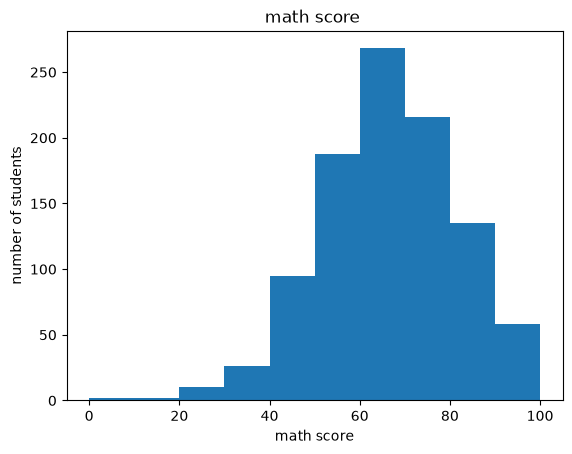

In [13]:
plt.hist(df["math score"])
plt.title("math score ")
plt.xlabel("math score")
plt.ylabel("number of students")
plt.show()

## observation
most students have math score btw 50 and 80 , there are fewer students with low high score 

## scatter plot 
i used a scatter plot to see the relationship between reading scores and math scores

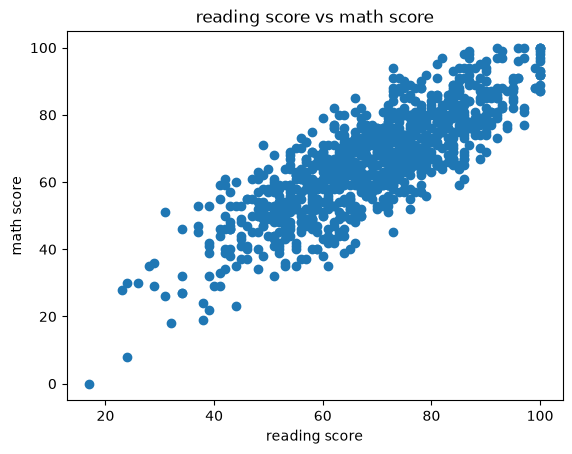

In [14]:
plt.scatter(df["reading score"],df["math score"])
plt.title("reading score vs math score")
plt.xlabel("reading score")
plt.ylabel("math score")
plt.show()

## observation 
the scatter plot shows that students with higher reading score usually also have higher math score 

## Bar Plot

A bar plot is useful for comparing values between different categories.

Here, I will compare the average scores of three subjects.

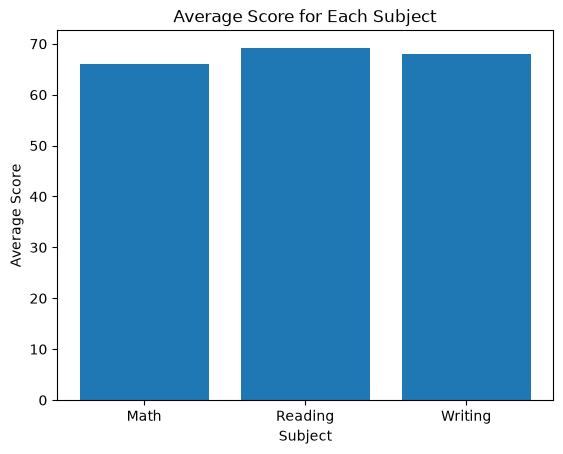

In [17]:
sub = ["Math", "Reading", "Writing"]

average_scores = [
    df["math score"].mean(),
    df["reading score"].mean(),
    df["writing score"].mean()
]

plt.bar(sub, average_scores)

plt.title("Average Score for Each Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.show()

the bar plot shows that the average reading score is the highest while the average math is the lowest 

## Line Plot

i used a line plot to show the math scores of the first 15 students 

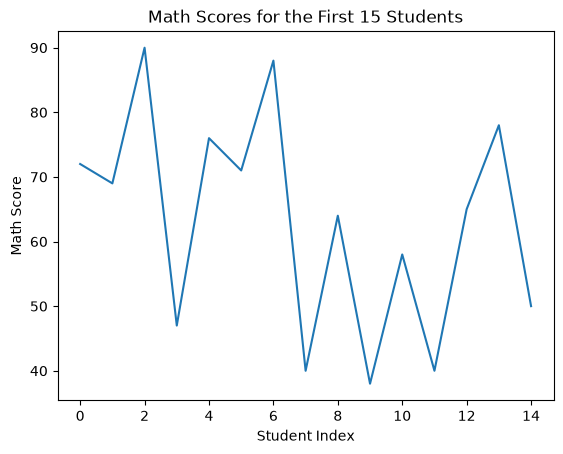

In [18]:
math_scores = df["math score"].head(15)

plt.plot(math_scores.values)

plt.title("Math Scores for the First 15 Students")
plt.xlabel("Student Index")
plt.ylabel("Math Score")

plt.show()

## observation 
 the line plot shows that the math scores are different from one student to another 

## Subplots

I used subplots to show two charts in one figure.

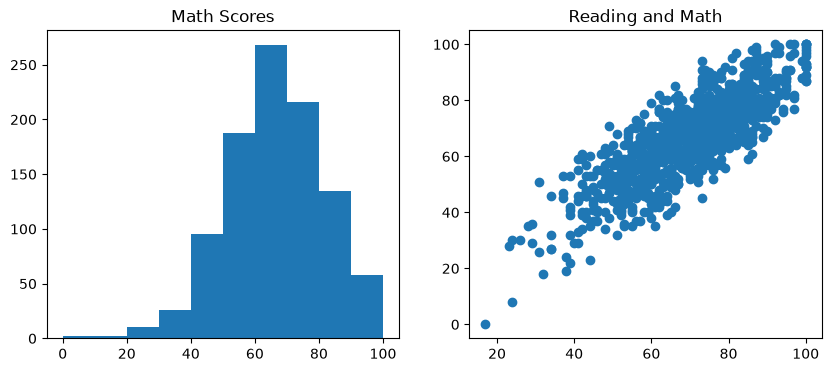

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(df["math score"], bins=10)
ax[0].set_title("Math Scores")

ax[1].scatter(df["reading score"], df["math score"])
ax[1].set_title("Reading and Math")

plt.show()

### Observation

The first chart shows math score distribution, The second chart shows that reading and math scores are related